In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
import src.utils as utils
from src.visualization import Visualization
import copy
from src.risk_computations import RiskComputations, diff_to_exponents, diff_sgd_vs_approx
from src.utils import save_risk_results


In [4]:
T=1000
sigma = 0.1
dim = 100

eta = 0.1
eta_range = np.logspace(-4, 2, 30)
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.2)
constant = ConstantSchedule(steps=T, base_lr=eta)
linear = WSDSchedule(steps=T, base_lr=eta, cooldown_len=1.)

beta = 0
x0 = np.array([1/i**beta for i in range(1, dim+1)])


schedules1 = [wsd, constant, linear]
schedules2 = copy.deepcopy(schedules1)

risks_computations_sgd = RiskComputations(model, x0, schedules=schedules1, schedules_names=["wsd", "constant", "linear"], sgd_class=SGD)
risks_computations_noisy_gd = RiskComputations(model, x0, schedules=schedules2, schedules_names=["wsd", "constant", "linear"], sgd_class=NoisyGD)

In [ ]:
exponents = np.linspace(0, 4, 40)
diff_results = diff_to_exponents(exponents=exponents, relative=True, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, eta_range=eta_range, x0=x0) 

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: invalid value encountered in

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


In [6]:
diff_approx_vs_sgd = diff_sgd_vs_approx(exponents=exponents, relative=True, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, schedules_names=["wsd", "constant", "linear"], eta_range=eta_range, x0=x0)

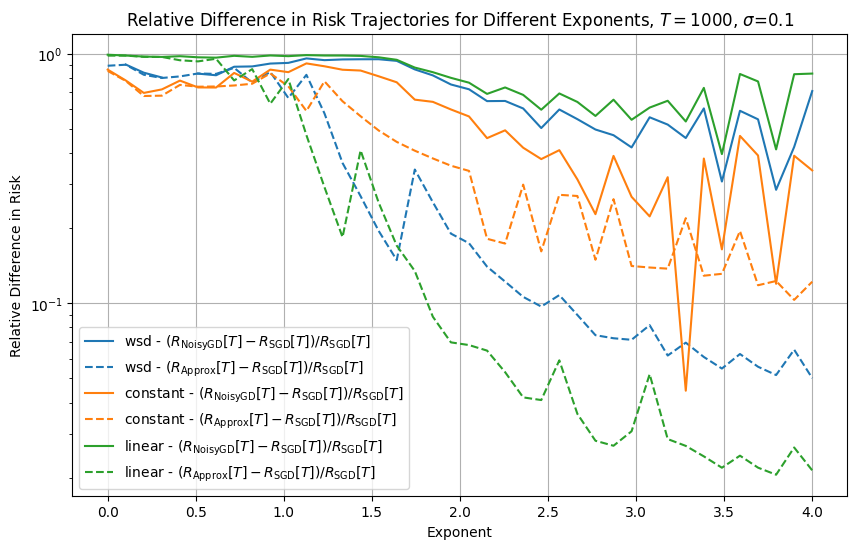

In [10]:
visu = Visualization(schedules=schedules1 ,schedules_name=["wsd", "constant", "linear"])
visu.plot_sgd_classes_comparison(
    risks_class1=diff_results, 
    risks_class2=diff_approx_vs_sgd,
    X=exponents, 
    title=rf"Relative Difference in Risk Trajectories for Different Exponents, $T={T}$, $\sigma$={sigma}", 
    xlabel="Exponent", 
    ylabel="Relative Difference in Risk",
    logscale=True,
    label_class1=r"$(R_\text{NoisyGD}[T] - R_\text{SGD}[T]) / R_\text{SGD}[T]$",
    label_class2=r"$(R_\text{Approx}[T] - R_\text{SGD}[T]) / R_\text{SGD}[T]$",
    savefig=True)

In [15]:
from src.utils import save_risk_results

save_risk_results(diff_results, "diff_sgd_noisy_gd_exponents")
save_risk_results(diff_approx_vs_sgd, "diff_sgd_approx_exponents")

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


'saved_files\\risks\\diff_sgd_approx_exponents'

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


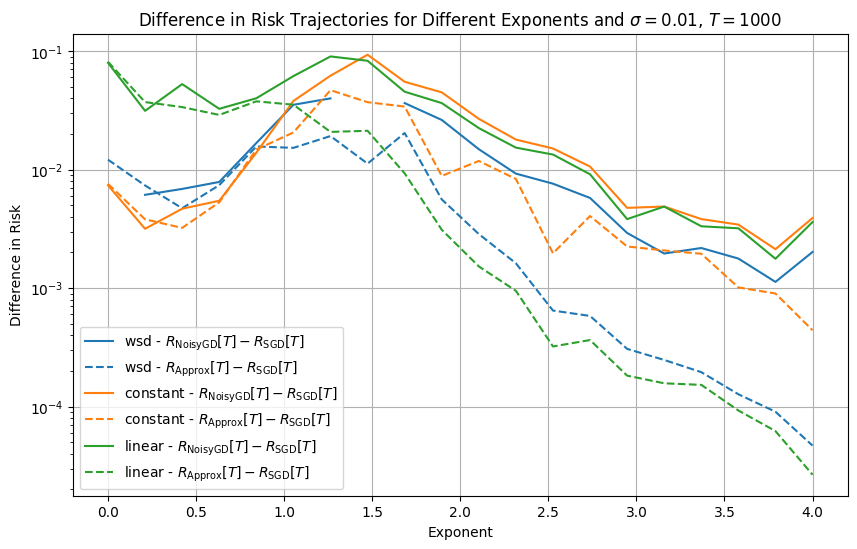

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: invalid value encountered in

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


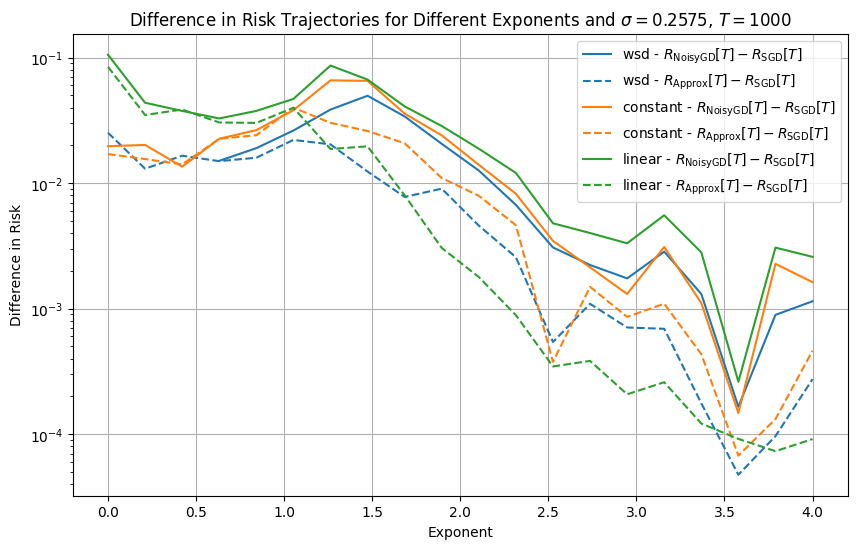

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: invalid value encountered in

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


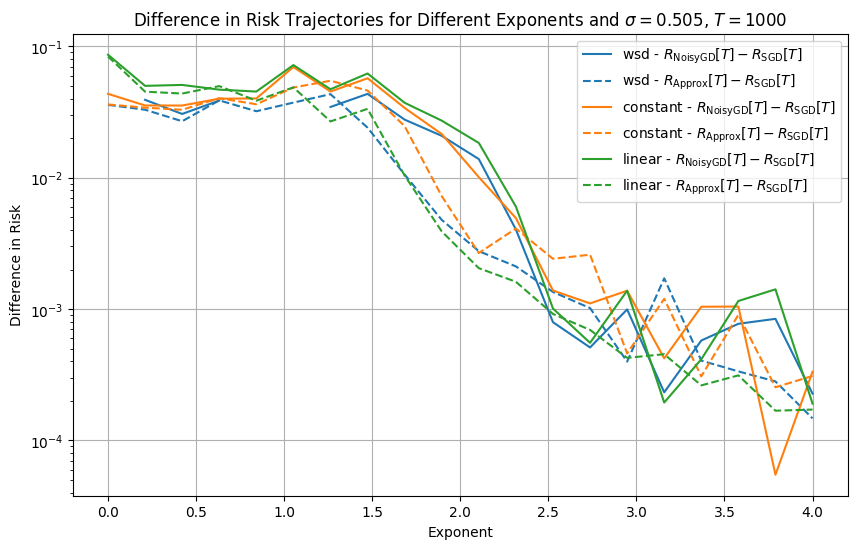

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scal

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


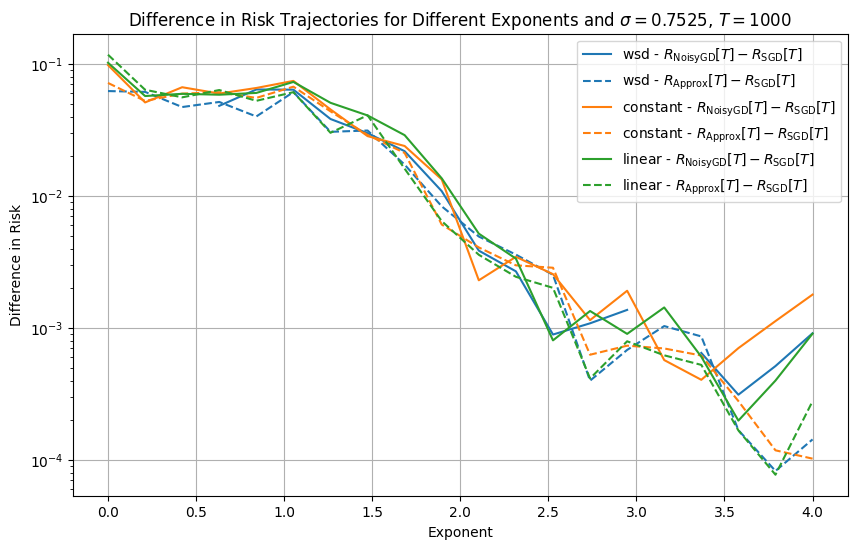

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encounter

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


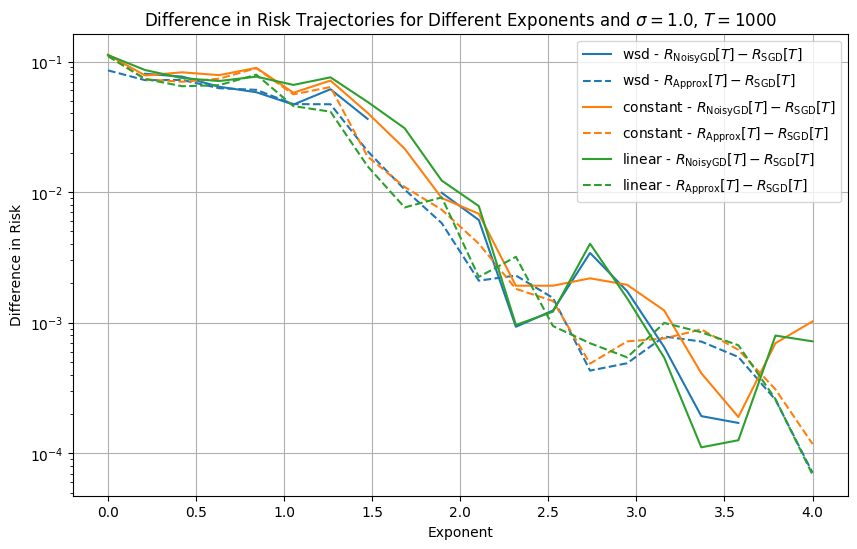

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


In [6]:
sigmas = np.linspace(0.01, 1, 5)
exponents = np.linspace(0, 4, 20)

for sigma in sigmas:
    diff_results = diff_to_exponents(exponents=exponents, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, eta_range=eta_range, x0=x0) 
    diff_approx_vs_sgd = diff_sgd_vs_approx(exponents=exponents, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, schedules_names=["wsd", "constant", "linear"], eta_range=eta_range, x0=x0) 
    visu = Visualization(schedules=schedules1 ,schedules_name=["wsd", "constant", "linear"])
    visu.plot_sgd_classes_comparison(
        risks_class1=diff_results, 
        risks_class2=diff_approx_vs_sgd,
        X=exponents, 
        title=rf"Difference in Risk Trajectories for Different Exponents and $\sigma={sigma}$, $T={T}$", 
        xlabel="Exponent", 
        ylabel="Difference in Risk",
        logscale=True,
        label_class1=r"$R_\text{NoisyGD}[T] - R_\text{SGD}[T]$",
        label_class2=r"$R_\text{Approx}[T] - R_\text{SGD}[T]$",
        savefig=True)
    
    save_risk_results(diff_results, "diff_sgd_noisy_gd_exponents")
    save_risk_results(diff_approx_vs_sgd, "diff_sgd_approx_exponents")

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encounter

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


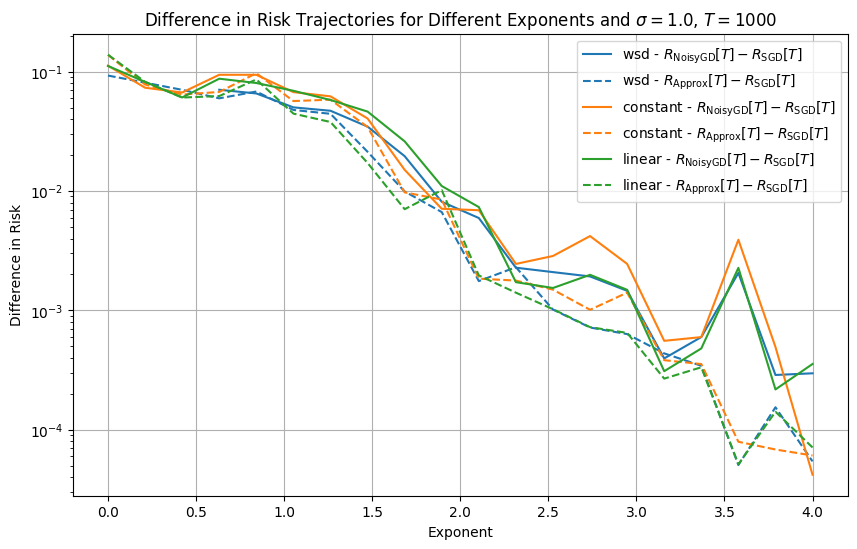

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scal

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


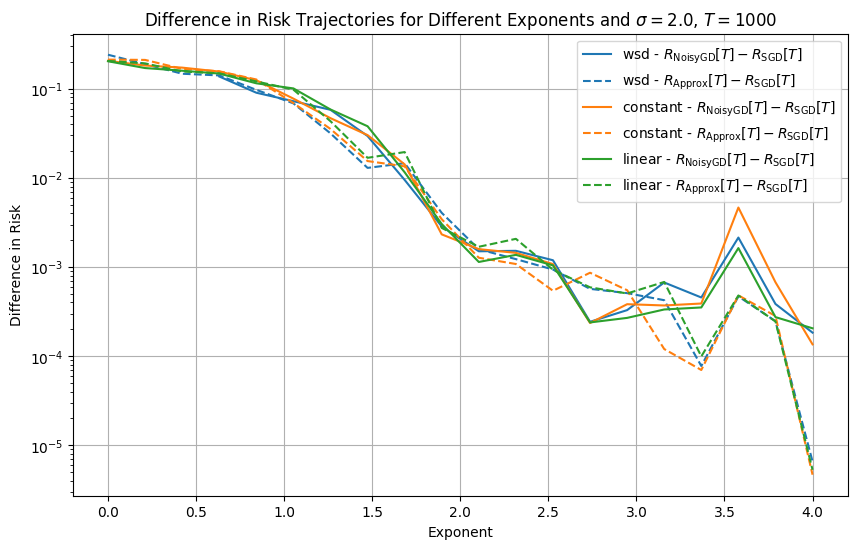

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: invalid value encountered in

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (bias_part + variance_part)


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))


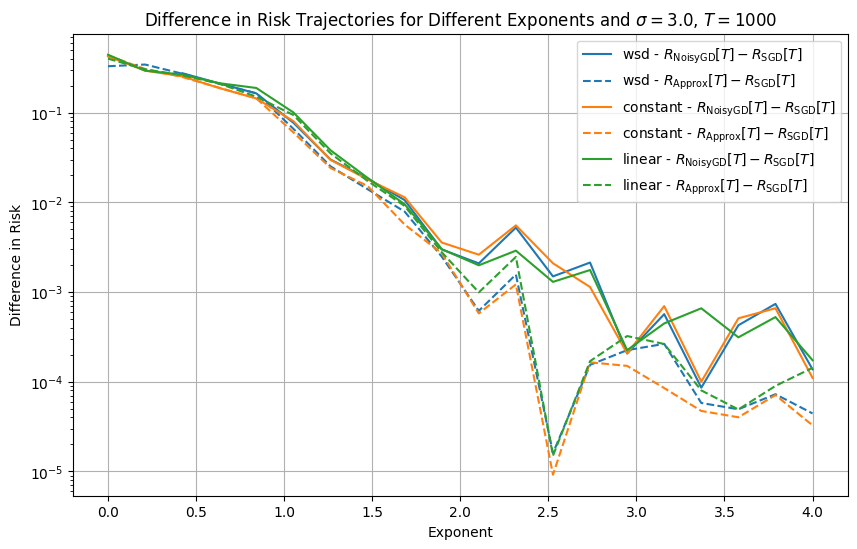

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarn

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


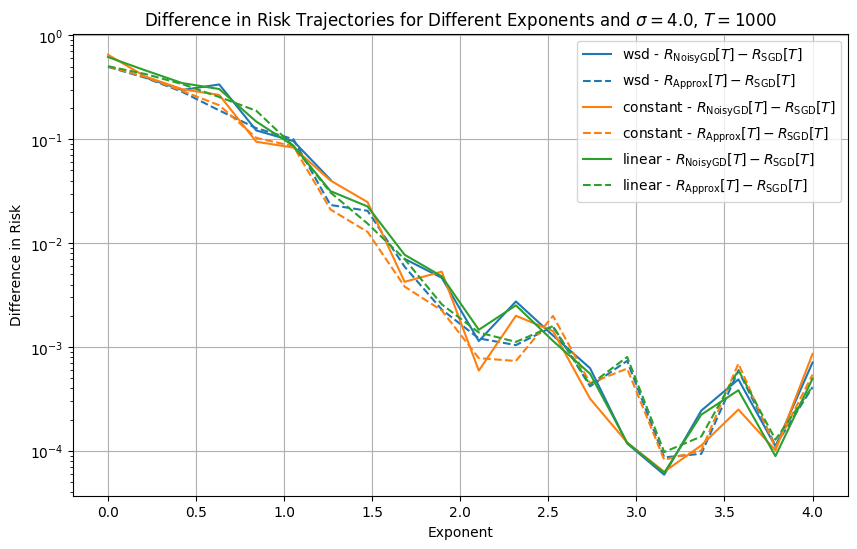

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:168: RuntimeWarning: overflow encountered in multiply
  m_t = P_t_vector * m_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:172: RuntimeWarning: overflow encountered in multiply
  v_t = P_t_vector * v_t + noise_t
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:157: RuntimeWarning: overflow encountered in scal

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:81: RuntimeWarning: overflow encountered in scalar add
  risk = 0.5 * (np.dot(lambda_vec, m_t) + np.dot(lambda_vec, v_t))
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m


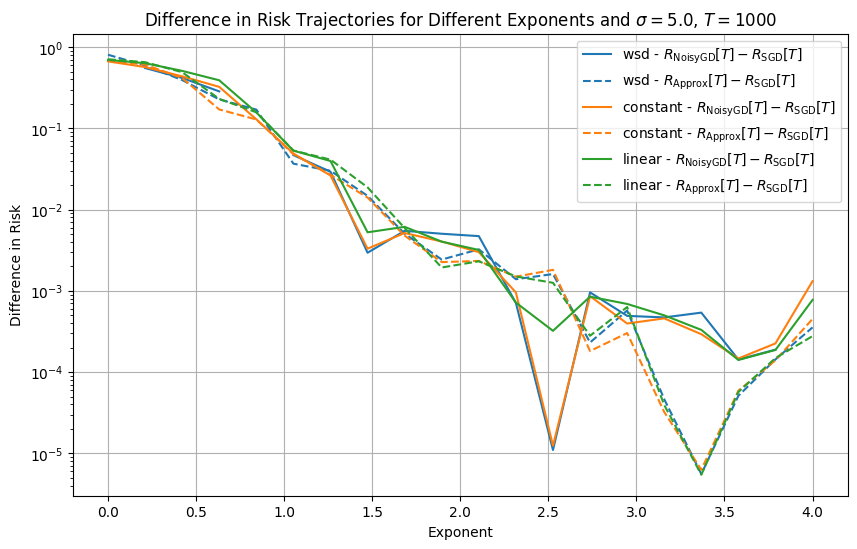

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


In [8]:
sigmas = np.linspace(1, 5, 5)
exponents = np.linspace(0, 4, 20)

for sigma in sigmas:
    diff_results = diff_to_exponents(exponents=exponents, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, eta_range=eta_range, x0=x0) 
    diff_approx_vs_sgd = diff_sgd_vs_approx(exponents=exponents, dim=dim, sigma=sigma, schedules1=schedules1, schedules2=schedules2, schedules_names=["wsd", "constant", "linear"], eta_range=eta_range, x0=x0) 
    visu = Visualization(schedules=schedules1 ,schedules_name=["wsd", "constant", "linear"])
    visu.plot_sgd_classes_comparison(
        risks_class1=diff_results, 
        risks_class2=diff_approx_vs_sgd,
        X=exponents, 
        title=rf"Difference in Risk Trajectories for Different Exponents and $\sigma={sigma}$, $T={T}$", 
        xlabel="Exponent", 
        ylabel="Difference in Risk",
        logscale=True,
        label_class1=r"$R_\text{NoisyGD}[T] - R_\text{SGD}[T]$",
        label_class2=r"$R_\text{Approx}[T] - R_\text{SGD}[T]$",
        savefig=True)
    
    save_risk_results(diff_results, "diff_sgd_noisy_gd_exponents")
    save_risk_results(diff_approx_vs_sgd, "diff_sgd_approx_exponents")